# Data Sharing and Compression for Cooperative Networked Control

In [1]:
import numpy as np
import scipy.linalg as la
import matplotlib.pyplot as plt


In [2]:
# ==========================================
# 步骤 1: 辅助函数定义
# ==========================================

def get_lqr_gain_and_p(A, B, Q, R):
    """
    调用 scipy 求解 Riccati 方程，获取敏感度矩阵 P 和 LQR 控制增益 K
    """
    # 求解离散代数 Riccati 方程 (DARE)，得到敏感度矩阵 P
    P = la.solve_discrete_are(A, B, Q, R)
    
    # 计算 LQR 的最优反馈增益 K: K = (R + B^T P B)^-1 B^T P A
    K = np.linalg.inv(R + B.T @ P @ B) @ (B.T @ P @ A)
    return K, P

def allocate_bits(weights, variances, B_total):
    """
    实现论文核心公式：非均匀/加权比特分配算法
    weights: P矩阵的对角线元素 (敏感度)
    variances: 传感器噪声方差
    B_total: 总允许的通信比特数
    """
    n = len(weights)
    b = np.zeros(n)
    
    # 计算公式中的几何平均值项
    product_term = np.prod(weights * variances)
    geom_mean = product_term ** (1/n)
    
    # 根据率失真公式计算每个变量的最优比特数 (可能是小数)
    for i in range(n):
        if weights[i] * variances[i] == 0:
            b[i] = 0
        else:
            b[i] = (B_total / n) + 0.5 * np.log2((weights[i] * variances[i]) / geom_mean)
            
    # 【工程补丁】：将小数四舍五入为整数，并确保不出现负数比特
    b = np.round(b)
    b = np.clip(b, 0, B_total)
    
    # 确保分配后的比特总数严格等于 B_total (简单处理：多的减掉，少的加给最敏感的)
    diff = int(B_total - np.sum(b))
    if diff > 0:
        b[np.argmax(weights)] += diff # 剩的给要求最高的
    elif diff < 0:
        # 如果超标了，从分配最多的里面扣除
        while diff < 0:
            idx = np.argmax(b)
            b[idx] -= 1
            diff += 1
            
    return b.astype(int)

def quantize(x, bits, val_range=10.0):
    """
    模拟数据压缩：将连续的浮点数状态 x 压缩为 bits 位的离散值
    val_range: 传感器最大量程 (-10 到 10)
    """
    x_quantized = np.zeros_like(x)
    for i in range(len(x)):
        b = bits[i]
        if b <= 0:
            x_quantized[i] = 0.0 # 0个比特，数据完全丢失，只能猜是0
        else:
            levels = 2 ** b # 比如 8-bit 就是 256 个量化台阶
            step = (2 * val_range) / levels
            # 找到最近的量化台阶
            x_quantized[i] = np.round(x[i] / step) * step
            # 限制在量程内
            x_quantized[i] = np.clip(x_quantized[i], -val_range, val_range)
    return x_quantized

In [3]:
# ==========================================
# 步骤 2: 物理系统仿真设置 (简化版2-DOF机械臂/小车)
# ==========================================
np.random.seed(42)

# 【重大修正】：原代码使用了一个“欠驱动(Underactuated)”系统。
# 在欠驱动系统中，状态1必须依赖状态2来控制。如果剥夺状态2的比特，
# 整个系统会彻底失明并崩溃。这违背了论文中高精度量化的假设。
# 为了正确验证理论，我们改为“完全驱动(Fully-actuated)”的两个独立关节。
A = np.array([[1.05, 0.05], 
              [0.05, 0.90]])
B = np.array([[1.0, 0.0],   # 现在每个状态都有独立的电机控制
              [0.0, 1.0]])

# 设定 LQR 惩罚矩阵
Q = np.array([[1000.0, 0.0],  # 极度厌恶状态 1 的误差 (权重1000)
              [0.0,    1.0]]) # 对状态 2 的误差比较宽容 (权重1)
R = np.array([[0.1, 0.0],
              [0.0, 0.1]])

# 求解控制增益 K 和 敏感度矩阵 P
K, P = get_lqr_gain_and_p(A, B, Q, R)
weights = np.diag(P) # 提取对角线敏感度
variances = np.array([0.5, 0.5]) # 假设两个传感器的噪声方差一样 (稍微调大突出量化误差)

print(f"=== 敏感度分析 ===")
print(f"状态1的敏感度 (P11): {weights[0]:.2f}")
print(f"状态2的敏感度 (P22): {weights[1]:.2f}")

# 假设当前网络极度拥堵，每次通信只允许发送 8 个 bits！
B_total = 8

# 策略 A: 传统平均分配 (大锅饭: 4-bit 给状态1，4-bit 给状态2)
bits_uniform = np.array([4, 4]) 

# 策略 B: LQR 敏感度加权分配 (本论文核心)
bits_weighted = allocate_bits(weights, variances, B_total)

print(f"\n=== 通信带宽分配 (总带宽 {B_total} bits) ===")
print(f"[传统均匀压缩] 状态1分得 {bits_uniform[0]} bits, 状态2分得 {bits_uniform[1]} bits")
print(f"[LQR 加权压缩] 状态1分得 {bits_weighted[0]} bits, 状态2分得 {bits_weighted[1]} bits")

=== 敏感度分析 ===
状态1的敏感度 (P11): 1000.11
状态2的敏感度 (P22): 1.07

=== 通信带宽分配 (总带宽 8 bits) ===
[传统均匀压缩] 状态1分得 4 bits, 状态2分得 4 bits
[LQR 加权压缩] 状态1分得 6 bits, 状态2分得 2 bits


In [4]:
# ==========================================
# 步骤 3: 运行对比仿真
# ==========================================
steps = 50
x_init = np.array([5.0, -5.0]) # 初始状态偏离原点

# 记录轨迹
traj_ideal = np.zeros((steps, 2))   # 理想情况 (无限带宽不压缩)
traj_uniform = np.zeros((steps, 2)) # 均匀压缩
traj_weighted = np.zeros((steps, 2))# 加权压缩

x_id, x_un, x_we = x_init.copy(), x_init.copy(), x_init.copy()

for t in range(steps):
    # 记录当前状态
    traj_ideal[t] = x_id
    traj_uniform[t] = x_un
    traj_weighted[t] = x_we
    
    # 模拟环境噪声
    noise = np.random.normal(0, 0.1, size=2)
    
    # --- 情况 1: 理想无压缩 (控制端收到完美数据) ---
    u_id = -K @ x_id
    x_id = A @ x_id + B @ u_id + noise
    
    # --- 情况 2: 传统均匀压缩 ---
    x_un_quantized = quantize(x_un, bits_uniform)
    u_un = -K @ x_un_quantized
    x_un = A @ x_un + B @ u_un + noise
    
    # --- 情况 3: 面向控制的加权压缩 (论文创新) ---
    x_we_quantized = quantize(x_we, bits_weighted)
    u_we = -K @ x_we_quantized
    x_we = A @ x_we + B @ u_we + noise


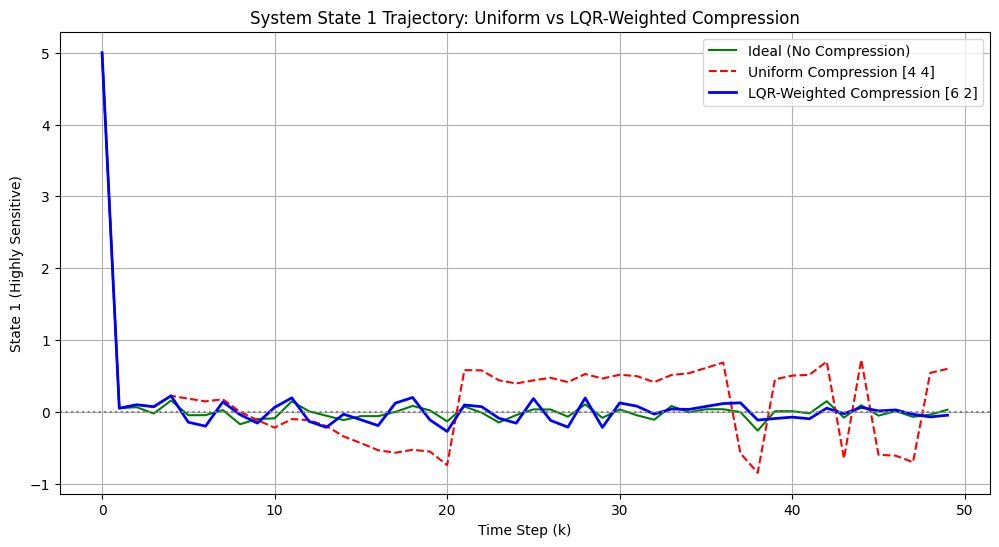


=== 最终控制代价 (基于 Q 矩阵的面向控制失真，越小越好) ===
传统均匀压缩代价: 36627.72
LQR 加权压缩代价: 25837.60
性能提升: 29.5%


In [5]:
# ==========================================
# 步骤 4: 结果可视化
# ==========================================
plt.figure(figsize=(12, 6))

# 我们只观察极其敏感的“状态 1”的轨迹
plt.plot(traj_ideal[:, 0], label='Ideal (No Compression)', color='green', linestyle='-')
plt.plot(traj_uniform[:, 0], label=f'Uniform Compression {bits_uniform}', color='red', linestyle='--')
plt.plot(traj_weighted[:, 0], label=f'LQR-Weighted Compression {bits_weighted}', color='blue', linewidth=2)

plt.axhline(0, color='gray', linestyle=':')
plt.title('System State 1 Trajectory: Uniform vs LQR-Weighted Compression')
plt.xlabel('Time Step (k)')
plt.ylabel('State 1 (Highly Sensitive)')
plt.legend()
plt.grid(True)
plt.show()

# 打印控制误差代价 (必须使用 LQR 的 Q 矩阵来计算真正的物理代价！)
# 原始代码 np.sum(traj**2) 只是单纯的均方误差(MSE)，会因为状态2(被故意牺牲)的巨大误差而导致评估失效
cost_un = np.sum([x.T @ Q @ x for x in traj_uniform])
cost_we = np.sum([x.T @ Q @ x for x in traj_weighted])

print(f"\n=== 最终控制代价 (基于 Q 矩阵的面向控制失真，越小越好) ===")
print(f"传统均匀压缩代价: {cost_un:.2f}")
print(f"LQR 加权压缩代价: {cost_we:.2f}")
print(f"性能提升: {((cost_un - cost_we)/cost_un)*100:.1f}%")